# Dataset

In [1]:
import os
import sys
import random
import warnings

# 1.1 Suppress System Verbosity & Warnings Before Compiling
warnings.filterwarnings('ignore', category=UserWarning, module='backend_interactivity')
warnings.filterwarnings('ignore', message='.*Type-based sharding.*')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Suppress core TensorFlow INFO/WARN logs
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # Dynamically allocate GPU memory footprint

# 1.2 Establish Strict Reproducibility Seeds
SEED = 17
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

# 1.3 Core Mathematical & Scientific Stack
import numpy as np
from scipy.integrate import solve_ivp
from numpy.lib.stride_tricks import sliding_window_view

np.random.seed(SEED)

# 1.4 Graphics & Visualization Configurations
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# Smart Backend Handling: Fall back to headless 'Agg' only if no display server exists
if 'IPython' in sys.modules:
    # If running in a Jupyter Notebook, allow standard inline plotting
    mpl.use('module://matplotlib_inline.backend_inline')
elif os.environ.get('DISPLAY') is None and not os.environ.get('WAYLAND_DISPLAY'):
    # Headless server fallback (prevents crash on remote SSH clusters without X11)
    mpl.use('Agg')

# 1.5 Deep Learning Framework (PyTorch version)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

SEED = 42

# Set global seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Enable deterministic behavior
torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


# =============================================================================
# 📊 SYSTEM DIAGNOSTICS & VERIFICATION
# =============================================================================

print("--------------------------------------------------")
print(f"📦 Environment Verification Successful")
print("--------------------------------------------------")
print(f"Python Version : {sys.version.split()[0]}")
print(f"NumPy Version  : {np.__version__}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Matplotlib     : {mpl.__version__} [Backend: {mpl.get_backend()}]")
print("--------------------------------------------------")

# Query Available Compute Hardware
num_cpus = torch.get_num_threads()
gpu_available = torch.cuda.is_available()
num_gpus = torch.cuda.device_count()

print(f"🖥️ Execution Hardware:")
print(f"   • CPUs Detected: {num_cpus}")
if gpu_available:
    print(f"   • GPUs Detected: {num_gpus} [{torch.cuda.get_device_name(0)}]")
else:
    print("   • GPUs Detected: 0 [Running on CPU Baseline]")
print("--------------------------------------------------")
print("✓ Environment locked. Ready for data ingestion.")

Running on: cuda
--------------------------------------------------
📦 Environment Verification Successful
--------------------------------------------------
Python Version : 3.9.13
NumPy Version  : 2.0.2
PyTorch Version: 2.7.1+cu118
Matplotlib     : 3.9.4 [Backend: module://matplotlib_inline.backend_inline]
--------------------------------------------------
🖥️ Execution Hardware:
   • CPUs Detected: 36
   • GPUs Detected: 1 [NVIDIA A100-PCIE-40GB]
--------------------------------------------------
✓ Environment locked. Ready for data ingestion.


In [2]:
def lorenz96_rhs_vec(t, state, F=8.0):
    """
    Vectorized Right-Hand Side (RHS) of the Lorenz 96 system.
    Exploits np.roll to efficiently evaluate periodic boundary conditions.
    
    Equations handled simultaneously:
        dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - x_i + F
    """
    # np.roll shifts elements along the axis. 
    # Shift -1 brings x_{i+1} to position i. Shift 2 brings x_{i-2} to position i.
    return (np.roll(state, -1) - np.roll(state, 2)) * np.roll(state, 1) - state + F


def integrate_lorenz96(state0, t_span, dt_eval, F=8.0):
    """
    Integrates the high-dimensional Lorenz 96 system using an explicit
    Adaptive Runge-Kutta method (RK45 via Scipy solve_ivp).
    
    Parameters:
        state0 (ndarray): Initial conditions vector of shape (N,).
        t_span (tuple): (t_start, t_end) integration window.
        dt_eval (float): The temporal sampling resolution for the ML data grid.
    """
    t_eval = np.arange(t_span[0], t_span[1], dt_eval)
    sol = solve_ivp(
        fun=lorenz96_rhs_vec, 
        t_span=t_span, 
        y0=state0,
        method='RK45', 
        t_eval=t_eval,
        args=(F,), 
        rtol=1e-8, 
        atol=1e-10  # Standard tolerances for high-dimensional chaotic tracking
    )
    return sol.t, sol.y.T


# -----------------------------------------------------------------------------
# ⚙️ Configuration & Boundary Init Setup
# -----------------------------------------------------------------------------
L96_N       = 40     # Dimension of the latitude circle grid
L96_F       = 8.0    # Forcing amplitude parameter (Fully chaotic regime)
L96_DT_ML   = 0.05   # Target downsampled sampling interval for ML windows

print(f"⏳ Initializing Lorenz 96 Data Generation (Grid Points N = {L96_N})...")

# Construct the initial unstable equilibrium state 
# We seed a tiny 0.01 perturbation at the center grid point to trigger wave growth
state0_96 = np.ones(L96_N) * L96_F
state0_96[L96_N // 2] += 0.01

# Phase 1: Transient Spin-up
# We integrate for 100 MTU to shed transient features and let planetary waves form natively.
print("  ↳ Executing 100 MTU spin-up phase to construct the chaotic manifold...")
t_spin96, X_spin96 = integrate_lorenz96(state0_96, [0, 100], L96_DT_ML, F=L96_F)

# CRITICAL MANIFOLD FIX: Extract the final state vector of the spin-up
# to serve as our legitimate, physical starting seed for the production run.
attractor_docked_state_96 = X_spin96[-1, :]
print("  ↳ Spin-up complete. System successfully stabilized onto the attractor.")

# Phase 2: Production Data Accumulation Run
# 5,000 MTU evaluated at Delta t = 0.05 yields exactly 100,000 spatial snapshots.
t96, X96 = integrate_lorenz96(attractor_docked_state_96, [0, 5000], L96_DT_ML, F=L96_F)

# -----------------------------------------------------------------------------
# 📊 Diagnostics Verification Matrix
# -----------------------------------------------------------------------------
print("\n📊 Dataset Verification Matrix:")
print("--------------------------------------------------")
print(f"  • Total Temporal Steps : {len(t96):,}")
print(f"  • Total Simulated Time : {t96[-1]:,.1f} Mean Time Units (MTU)")
print(f"  • Tensor Spatial Shape : {X96.shape} (Steps × Grid Points)")
print("--------------------------------------------------")
print(f"  • Domain Absolute Bounds  : [{X96.min():.2f}, {X96.max():.2f}]")
print(f"  • Ensemble Trajectory Mean: {X96.mean():.4f}  (Theoretical Baseline ≈ 2.38 for F=8)")
print("--------------------------------------------------")
print("✓ Lorenz 96 spatial ground truth compiled and locked in memory.")

⏳ Initializing Lorenz 96 Data Generation (Grid Points N = 40)...
  ↳ Executing 100 MTU spin-up phase to construct the chaotic manifold...
  ↳ Spin-up complete. System successfully stabilized onto the attractor.

📊 Dataset Verification Matrix:
--------------------------------------------------
  • Total Temporal Steps : 100,000
  • Total Simulated Time : 5,000.0 Mean Time Units (MTU)
  • Tensor Spatial Shape : (100000, 40) (Steps × Grid Points)
--------------------------------------------------
  • Domain Absolute Bounds  : [-10.88, 16.56]
  • Ensemble Trajectory Mean: 2.3400  (Theoretical Baseline ≈ 2.38 for F=8)
--------------------------------------------------
✓ Lorenz 96 spatial ground truth compiled and locked in memory.


In [3]:
# =============================================================================
# 📊 DATA PARTITIONING & STABILIZED Z-SCORE NORMALIZATION
# =============================================================================

def split_data(X, train_frac=0.70, val_frac=0.15):
    """
    Splits a continuous time-series matrix into chronological, non-overlapping
    blocks for training, validation, and testing to preserve temporal dynamics.
    
    Parameters:
        X (ndarray): Source feature array of shape (n_samples, n_features).
        train_frac (float): Proportion of data allocated for training.
        val_frac (float): Proportion of data allocated for validation.
        
    Returns:
        X_train, X_val, X_test (ndarrays)
    """
    n = len(X)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    
    X_train = X[:n_train]
    X_val   = X[n_train:n_train + n_val]
    X_test  = X[n_train + n_val:]
    
    return X_train, X_val, X_test


def normalize(X_train, X_val, X_test):
    """
    Computes Z-score normalization statistics strictly from the training set,
    and applies them uniformly across all partitions to prevent data leakage.
    
    Includes a numerical stability guard (epsilon) against division-by-zero.
    """
    mu  = X_train.mean(axis=0)
    sig = X_train.std(axis=0)
    
    # Defensive epsilon guard to protect against stable/zero-variance channels
    eps = 1e-15
    
    X_train_scaled = (X_train - mu) / (sig + eps)
    X_val_scaled   = (X_val - mu) / (sig + eps)
    X_test_scaled  = (X_test - mu) / (sig + eps)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, mu, sig

# -----------------------------------------------------------------------------
# 🌐 Execution: Lorenz 96 Splitting & Normalization
# -----------------------------------------------------------------------------
TR_F, VA_F = 0.70, 0.15
TE_F = 1.0 - (TR_F + VA_F)
X96_train, X96_val, X96_test = split_data(X96, train_frac=TR_F, val_frac=VA_F)
X96_train_n, X96_val_n, X96_test_n, mu96, sig96 = normalize(X96_train, X96_val, X96_test)

print("\n📊 Lorenz 96 Spatiotemporal Splits:")
print("--------------------------------------------------")
print(f"  • Train Set : {X96_train.shape} ({TR_F*100:.0f}%)")
print(f"  • Val Set   : {X96_val.shape}  ({VA_F*100:.0f}%)")
print(f"  • Test Set  : {X96_test.shape} ({TE_F*100:.0f}%)")
print(f"  • Mu (Train, first 3 points)   : {mu96[:3].round(3)}")
print(f"  • Sigma (Train, first 3 points): {sig96[:3].round(3)}")
print("--------------------------------------------------")
print("✓ Chronological splitting completed. Feature arrays scaled and locked.")


📊 Lorenz 96 Spatiotemporal Splits:
--------------------------------------------------
  • Train Set : (70000, 40) (70%)
  • Val Set   : (15000, 40)  (15%)
  • Test Set  : (15000, 40) (15%)
  • Mu (Train, first 3 points)   : [2.305 2.35  2.324]
  • Sigma (Train, first 3 points): [3.637 3.658 3.663]
--------------------------------------------------
✓ Chronological splitting completed. Feature arrays scaled and locked.


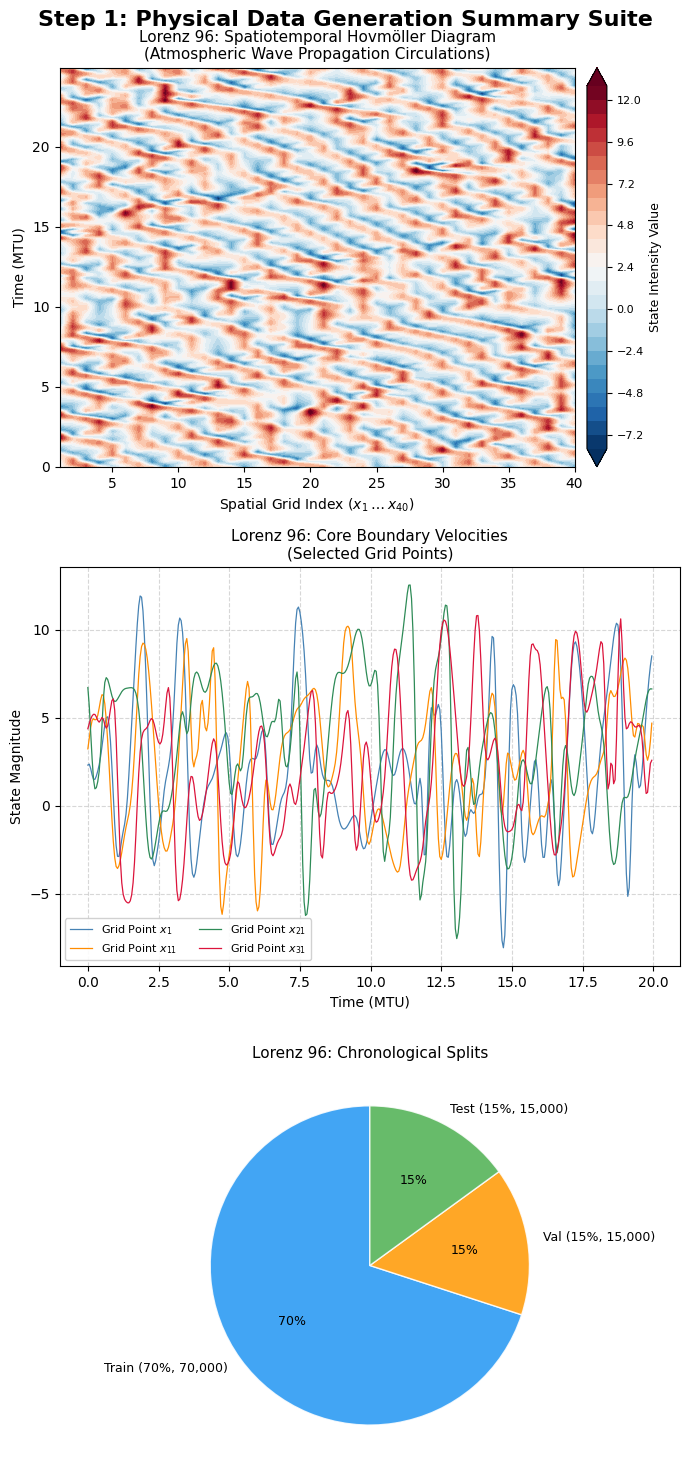

✓ Diagnostic visualization suite compiled successfully. Frame locked in file: 'step1_data_generation.png'


In [4]:
# =============================================================================
# 📊 STEP 1.5: COMPREHENSIVE DATASET DIAGNOSTIC DASHBOARD
# =============================================================================

# Define a unified high-contrast color palette for data partitioning
colors_split = ['#2196F3', '#FF9800', '#4CAF50']  # Blue (Train), Orange (Val), Green (Test)

# Calculate exact percentages dynamically to reflect upstream splits accurately
total_96 = len(X96)
p96_tr, p96_va, p96_te = len(X96_train)/total_96*100, len(X96_val)/total_96*100, len(X96_test)/total_96*100

# Initialize structural canvas
fig = plt.figure(figsize=(7, 15))
fig.suptitle("Step 1: Physical Data Generation Summary Suite", fontsize=16, fontweight='bold', y=0.98)

# -----------------------------------------------------------------------------
# ── Panel 1: L96 Spatiotemporal Hovmöller Diagram
# -----------------------------------------------------------------------------
ax4 = fig.add_subplot(311)
t_end_hov = 500  # Captures the first 25 MTU for spatial propagation mapping
hov = ax4.contourf(np.arange(1, L96_N + 1), t96[:t_end_hov], X96[:t_end_hov, :],
                   levels=30, cmap='RdBu_r', extend='both')
cbar = plt.colorbar(hov, ax=ax4, pad=0.02)
cbar.set_label('State Intensity Value', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax4.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax4.set_ylabel('Time (MTU)', fontsize=10)
ax4.set_title('Lorenz 96: Spatiotemporal Hovmöller Diagram\n(Atmospheric Wave Propagation Circulations)', fontsize=11)

# -----------------------------------------------------------------------------
# ── Panel 2: L96 Grid Coordinate Points
# -----------------------------------------------------------------------------
ax5 = fig.add_subplot(312)
t_plot_lim_96 = 400  # Captures first 20 MTU at Delta t = 0.05
target_channels = [0, 10, 20, 30]
line_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for idx, col in zip(target_channels, line_colors):
    ax5.plot(t96[:t_plot_lim_96], X96[:t_plot_lim_96, idx], color=col, lw=0.9, label=f'Grid Point $x_{{{idx+1}}}$')

# CRITICAL FIX: Moved configuration attributes outside the plotting loop
ax5.set_xlabel('Time (MTU)', fontsize=10)
ax5.set_ylabel('State Magnitude', fontsize=10)
ax5.set_title('Lorenz 96: Core Boundary Velocities\n(Selected Grid Points)', fontsize=11)
ax5.legend(loc='lower left', fontsize=8, ncol=2, framealpha=0.9)
ax5.grid(True, linestyle='--', alpha=0.5)

# -----------------------------------------------------------------------------
# ── Panel 3: L96 Spatiotemporal Data Partitioning
# -----------------------------------------------------------------------------
ax6 = fig.add_subplot(313)
sizes96 = [len(X96_train), len(X96_val), len(X96_test)]
labels96 = [
    f'Train ({p96_tr:.0f}%, {len(X96_train):,})', 
    f'Val ({p96_va:.0f}%, {len(X96_val):,})', 
    f'Test ({p96_te:.0f}%, {len(X96_test):,})'
]
ax6.pie(sizes96, labels=labels96, colors=colors_split, autopct='%1.0f%%', startangle=90, 
        textprops={'fontsize': 9}, wedgeprops={'alpha': 0.85, 'edgecolor': 'w', 'linewidth': 1})
ax6.set_title('Lorenz 96: Chronological Splits', fontsize=11)

# -----------------------------------------------------------------------------
# ── Canvas Serialization & Output Pipeline
# -----------------------------------------------------------------------------
plt.tight_layout()

# Save image into execution tree directory before displaying to prevent buffer flushing loss
output_filename = 'step1_data_generation.png'
plt.savefig(output_filename, dpi=150, bbox_inches='tight')

# Render inline if running interactively
if mpl.get_backend() != 'Agg':
    plt.show()
else:
    plt.close(fig)  # Explicitly clear memory handles on headless environments

print(f"✓ Diagnostic visualization suite compiled successfully. Frame locked in file: '{output_filename}'")

In [5]:
# =============================================================================
# 📐 STEP 2: EFFICIENT SLIDING WINDOW DATA ENGINEERING TENSORS
# =============================================================================

# 2.1 Hyperparameters Mapping
WINDOW  = 10    # Number of past historical time steps used as model input (w)
HORIZON = 1     # Prediction lead time: steps ahead to target forecast (h)


def make_windows(X, w=10, h=1):
    """
    Convert a continuous time series array into (input-window, target-state) pairs.
    Handles both 1D and 2D state arrays deterministically.

    Parameters
    ----------
    X : np.ndarray, shape (T, n_features) or (T,)
        Full chronological time series. T = timesteps, n_features = variables.
    w : int, default=10
        Window length (input lookback history history size).
    h : int, default=1
        Forecasting horizon (exactly how many steps ahead to predict).

    Returns
    -------
    Xw : np.ndarray, shape (n_samples, w, n_features), dtype=np.float32
         Feature windows formatted for deep learning architectures.
    Yw : np.ndarray, shape (n_samples, n_features), dtype=np.float32
         Target states safely shifted by the horizon (h).
    """
    # 1. Create overlapping memory views along the temporal axis (axis 0)
    sv = sliding_window_view(X, w, axis=0)

    if X.ndim == 2:
        # Reorder strides from (samples, features, w) -> (samples, w, features)
        # Match expected deep learning shapes: (batch, time_steps, channels)
        sv = sv.transpose(0, 2, 1)
    else:
        sv = sv[:, np.newaxis]  # 1D single-feature channel fallback

    # 2. Compute total valid windows reserving space for the future forecasting horizon
    n_samples = sv.shape[0] - h

    # 3. Slice and cast features and targets up-front to float32 for accelerated training
    Xw = sv[:n_samples].astype(np.float32)
    
    # FIX: Factor horizon 'h' explicitly into target slicing to prevent misalignments if h > 1
    Yw = X[w + h - 1 : w + h - 1 + n_samples].astype(np.float32)
    
    return Xw, Yw


# =============================================================================
# ⏳ AUTOMATED TRAIN / VAL / TEST WINDOW PROCESSING PIPELINE
# =============================================================================
print("⏳ Restructuring scaled arrays into sliding window tensor pairs...")

# 2.2 Define target mappings loop structures to avoid boilerplate code
systems = {
    "L96": {"train": X96_train_n, "val": X96_val_n, "test": X96_test_n}
}

# 2.3 Process and assign all subsets dynamically into memory variables
X96_win_tr, Y96_tr = make_windows(systems["L96"]["train"], WINDOW, HORIZON)
X96_win_vl, Y96_vl = make_windows(systems["L96"]["val"],   WINDOW, HORIZON)
X96_win_te, Y96_te = make_windows(systems["L96"]["test"],  WINDOW, HORIZON)

# Extract final feature channel dimensionality tracking
L96_N = X96_train_n.shape[1]    # 40 (spatial grid zones)

# =============================================================================
# 📊 FINAL GEOMETRY VERIFICATION REPORT
# =============================================================================
print("\n📊 Windowed Data Tensor Verification Matrix:")
print("----------------------------------------------------------------------")
print(f"🌐 Lorenz 96 Train Inputs (Xw) : {X96_win_tr.shape} | Targets (Yw): {Y96_tr.shape}")
print(f"🌐 Lorenz 96 Val Inputs   (Xw) : {X96_win_vl.shape} | Targets (Yw): {Y96_vl.shape}")
print(f"🌐 Lorenz 96 Test Inputs  (Xw) : {X96_win_te.shape} | Targets (Yw): {Y96_te.shape}")
print("----------------------------------------------------------------------")
print("✓ [OK] Step 2 data pipeline finalized. Core shapes ready for training tensors.")

⏳ Restructuring scaled arrays into sliding window tensor pairs...

📊 Windowed Data Tensor Verification Matrix:
----------------------------------------------------------------------
🌐 Lorenz 96 Train Inputs (Xw) : (69990, 10, 40) | Targets (Yw): (69990, 40)
🌐 Lorenz 96 Val Inputs   (Xw) : (14990, 10, 40) | Targets (Yw): (14990, 40)
🌐 Lorenz 96 Test Inputs  (Xw) : (14990, 10, 40) | Targets (Yw): (14990, 40)
----------------------------------------------------------------------
✓ [OK] Step 2 data pipeline finalized. Core shapes ready for training tensors.


# Learning Models

In [6]:
import itertools

In [7]:
# =============================================================================
# 🧱 STEP 3: DEEP LEARNING TRAINING PIPELINE
# =============================================================================

def train_and_search(model_builder, 
                     Xtr, Ytr, Xvl, Yvl,
                     BATCH=[64,128,256],
                     L_RATE=[1e-3,1e-4,1e-5],
                     EPOCHS=[5,10,50],
                     name="MLP"):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_global_loss = float("inf")
    best_params = None
    best_state = None

    # Tutte le combinazioni degli iperparametri
    for batch_size, lr, epochs in itertools.product(BATCH, L_RATE, EPOCHS):

        print("\n============================================================")
        print(f"🔍 Testing combination:")
        print(f"   batch_size = {batch_size}")
        print(f"   lr         = {lr}")
        print(f"   epochs     = {epochs}")
        print("============================================================")

        # Ricostruisci un modello nuovo
        model = model_builder().to(device)

        # Optimizer & loss
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        # Dataloaders
        train_loader = DataLoader(
            TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                          torch.tensor(Ytr, dtype=torch.float32)),
            batch_size=batch_size, shuffle=True
        )

        val_loader = DataLoader(
            TensorDataset(torch.tensor(Xvl, dtype=torch.float32),
                          torch.tensor(Yvl, dtype=torch.float32)),
            batch_size=batch_size, shuffle=False
        )

        # Training senza early stopping
        for epoch in range(1, epochs + 1):

            # -------------------------
            # TRAINING
            # -------------------------
            model.train()
            train_losses = []
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()
                pred = model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                optimizer.step()
                train_losses.append(loss.item())

            train_loss = sum(train_losses) / len(train_losses)

            # -------------------------
            # VALIDATION
            # -------------------------
            model.eval()
            val_losses = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    val_losses.append(criterion(pred, yb).item())

            val_loss = sum(val_losses) / len(val_losses)

            print(f"Epoch {epoch:03d}/{epochs} | "
                  f"train_loss = {train_loss:.6f} | "
                  f"val_loss = {val_loss:.6f}")

        # Fine training → valutazione finale
        final_val_loss = val_loss
        print(f"→ Final val_loss = {final_val_loss:.6f}")

        # Aggiorna best model globale
        if final_val_loss < best_global_loss:
            best_global_loss = final_val_loss
            best_params = (batch_size, lr, epochs)
            best_state = model.state_dict()
            print("⭐ New best model found!")

    # Salva il best model globale
    torch.save(best_state, f"{name}_BEST.pt")

    print("\n============================================================")
    print("🏆 BEST MODEL FOUND")
    print(f"   batch_size = {best_params[0]}")
    print(f"   lr         = {best_params[1]}")
    print(f"   epochs     = {best_params[2]}")
    print(f"   best val_loss = {best_global_loss:.6f}")
    print(f"   Saved as: {name}_BEST.pt")
    print("============================================================")

    return best_state, best_params, best_global_loss


In [9]:
# =============================================================================
print('\n⏳ Step 3.1: Mlp...')

class MLP(nn.Module):
    def __init__(self, n_features, window):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(window * n_features, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_features)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

# =============================================================================
# ⏳ PIPELINE EXECUTION LOOP
# =============================================================================
model_builder = lambda: MLP(n_features=L96_N, window=WINDOW)
print('\n🏗️  Training MLP...')
mlp, mlp_params, mlp_loss = train_and_search(
    model_builder,
    X96_win_tr, Y96_tr,
    X96_win_vl, Y96_vl,
    name="MLP"
)


⏳ Step 3.1: Mlp...

🏗️  Training MLP...

🔍 Testing combination:
   batch_size = 64
   lr         = 0.001
   epochs     = 5
Epoch 001/5 | train_loss = 0.115399 | val_loss = 0.036115
Epoch 002/5 | train_loss = 0.026537 | val_loss = 0.022523
Epoch 003/5 | train_loss = 0.018790 | val_loss = 0.017754
Epoch 004/5 | train_loss = 0.015064 | val_loss = 0.014889
Epoch 005/5 | train_loss = 0.012628 | val_loss = 0.012522
→ Final val_loss = 0.012522
⭐ New best model found!

🔍 Testing combination:
   batch_size = 64
   lr         = 0.001
   epochs     = 10
Epoch 001/10 | train_loss = 0.114833 | val_loss = 0.034505
Epoch 002/10 | train_loss = 0.025973 | val_loss = 0.022232
Epoch 003/10 | train_loss = 0.018033 | val_loss = 0.017758
Epoch 004/10 | train_loss = 0.014385 | val_loss = 0.015272
Epoch 005/10 | train_loss = 0.011963 | val_loss = 0.011642
Epoch 006/10 | train_loss = 0.010478 | val_loss = 0.010502
Epoch 007/10 | train_loss = 0.009564 | val_loss = 0.009334
Epoch 008/10 | train_loss = 0.008783 

In [ ]:
# =============================================================================
print('\n⏳ Step 3.2: CNN...')

class CausalConv1d(nn.Module):
    """Conv1D con padding causale esplicito (equivalente a TF padding='causal')."""
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.pad = kernel_size - 1
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size)

    def forward(self, x):
        # x: (batch, time, features)
        x = x.transpose(1, 2)  # → (batch, features, time)
        x = F.pad(x, (self.pad, 0))  # causal padding: solo a sinistra
        x = self.conv(x)
        return x.transpose(1, 2)  # → (batch, time, channels)


class CNN(nn.Module):
    def __init__(self, n_features, window):
        super().__init__()

        self.conv1 = CausalConv1d(n_features, 64, kernel_size=3)
        self.conv2 = CausalConv1d(64, 64, kernel_size=3)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(window * 64, 128)
        self.fc2 = nn.Linear(128, n_features)

    def forward(self, x):
        # x: (batch, window, n_features)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# =============================================================================
# ⏳ PIPELINE EXECUTION LOOP
# =============================================================================
model_builder = lambda: CNN(n_features=L96_N, window=WINDOW)
print('\n🏗️  Training CNN...')
cnn, cnn_params, cnn_loss = train_and_search(
    model_builder,
    X96_win_tr, Y96_tr,
    X96_win_vl, Y96_vl,
    name="CNN"
)


⏳ Step 3.2: CNN...

🏗️  Training CNN...

🔍 Testing combination:
   batch_size = 64
   lr         = 0.001
   epochs     = 5
Epoch 001/5 | train_loss = 0.307103 | val_loss = 0.123582
Epoch 002/5 | train_loss = 0.062620 | val_loss = 0.039303
Epoch 003/5 | train_loss = 0.027900 | val_loss = 0.024687
Epoch 004/5 | train_loss = 0.019661 | val_loss = 0.021545
Epoch 005/5 | train_loss = 0.015599 | val_loss = 0.016568
→ Final val_loss = 0.016568
⭐ New best model found!

🔍 Testing combination:
   batch_size = 64
   lr         = 0.001
   epochs     = 10
Epoch 001/10 | train_loss = 0.295008 | val_loss = 0.112499
Epoch 002/10 | train_loss = 0.057365 | val_loss = 0.036514
Epoch 003/10 | train_loss = 0.027089 | val_loss = 0.022198
Epoch 004/10 | train_loss = 0.019177 | val_loss = 0.018186
Epoch 005/10 | train_loss = 0.015361 | val_loss = 0.017034
Epoch 006/10 | train_loss = 0.012886 | val_loss = 0.012535
Epoch 007/10 | train_loss = 0.011511 | val_loss = 0.013386
Epoch 008/10 | train_loss = 0.010179 

In [ ]:
# =============================================================================
print('\n⏳ Step 3.3: ESN...')

n_reservoir=[500,750,1000]
spectral_radius=[0.8,0.9,1.0]
ridge_alpha=[1e-5,1e-6,1e-7]

class ESN(nn.Module):
    def __init__(self,
                 n_features,
                 window,
                 n_reservoir=800,
                 spectral_radius=0.9,
                 sparsity=0.95,
                 leak_rate=1.0,
                 ridge_alpha=1e-6,
                 device="cpu"):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.n_reservoir = n_reservoir
        self.leak_rate = leak_rate
        self.ridge_alpha = ridge_alpha
        self.device = torch.device(device)

        # Input weights: (n_reservoir, n_features)
        self.W_in = torch.empty(n_reservoir, n_features, device=self.device)
        nn.init.uniform_(self.W_in, -0.5, 0.5)

        # Reservoir weights (sparse)
        W = torch.randn(n_reservoir, n_reservoir, device=self.device)
        mask = (torch.rand_like(W) > sparsity).float()
        W = W * mask

        # Normalize spectral radius
        eigvals = torch.linalg.eigvals(W).abs()
        rho = eigvals.max().real
        W = W * (spectral_radius / rho)

        self.W = W

        # Readout weights (to be learned)
        self.W_out = nn.Parameter(torch.zeros(n_features, n_reservoir))

    @torch.no_grad()
    def fit(self, X, Y, washout=50):
        """
        X: (N, window, n_features)
        Y: (N, n_features)
        """
        X = X.to(self.device)
        Y = Y.to(self.device)

        N = X.shape[0]
        states = []

        for i in range(N):
            x_res = torch.zeros(self.n_reservoir, device=self.device)

            # feed the window through the reservoir
            for t in range(self.window):
                u_t = X[i, t]
                pre = self.W_in @ u_t + self.W @ x_res
                x_res = (1 - self.leak_rate) * x_res + self.leak_rate * torch.tanh(pre)

            states.append(x_res.clone())

        R = torch.stack(states)  # (N, n_reservoir)

        # Ridge regression: W_out = Y R^T (R R^T + αI)^(-1)
        Rt = R.T
        A = Rt @ R + self.ridge_alpha * torch.eye(self.n_reservoir, device=self.device)
        B = Rt @ Y
        self.W_out.data = torch.linalg.solve(A, B).T

    def forward(self, X):
        """
        X: (batch, window, n_features)
        Output: (batch, n_features)
        """
        batch = X.shape[0]
        X = X.to(self.device)

        outputs = []
        for i in range(batch):
            x_res = torch.zeros(self.n_reservoir, device=self.device)

            for t in range(self.window):
                u_t = X[i, t]
                pre = self.W_in @ u_t + self.W @ x_res
                x_res = (1 - self.leak_rate) * x_res + self.leak_rate * torch.tanh(pre)

            y = self.W_out @ x_res
            outputs.append(y)

        return torch.stack(outputs, dim=0)

def esn_train_and_search(model_builder,
                         Xtr, Ytr, Xvl, Yvl,
                         N_RES=[500, 750, 1000],
                         SPECT=[0.8, 0.9, 1.0],
                         RIDGE=[1e-5, 1e-6, 1e-7],
                         name="ESN"):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_global_loss = float("inf")
    best_params = None
    best_state = None

    # Tutte le combinazioni degli iperparametri ESN
    for n_res, sr, ra in itertools.product(N_RES, SPECT, RIDGE):

        print("\n============================================================")
        print("🔍 Testing ESN combination:")
        print(f"   n_reservoir    = {n_res}")
        print(f"   spectral_radius = {sr}")
        print(f"   ridge_alpha     = {ra}")
        print("============================================================")

        # Ricostruisci un modello ESN nuovo
        model = model_builder(n_reservoir=n_res,
                              spectral_radius=sr,
                              ridge_alpha=ra).to(device)

        # -------------------------
        # FIT (training ESN)
        # -------------------------
        model.fit(torch.tensor(Xtr, dtype=torch.float32),
                  torch.tensor(Ytr, dtype=torch.float32))

        # -------------------------
        # VALIDATION
        # -------------------------
        model.eval()
        criterion = nn.MSELoss()

        with torch.no_grad():
            Xvl_t = torch.tensor(Xvl, dtype=torch.float32).to(device)
            Yvl_t = torch.tensor(Yvl, dtype=torch.float32).to(device)
            pred = model(Xvl_t)
            val_loss = criterion(pred, Yvl_t).item()

        print(f"→ Validation loss = {val_loss:.6f}")

        # -------------------------
        # BEST MODEL UPDATE
        # -------------------------
        if val_loss < best_global_loss:
            best_global_loss = val_loss
            best_params = (n_res, sr, ra)
            best_state = model.state_dict()
            print("⭐ New best ESN found!")

    # Ricostruisci il best model e carica i pesi
    best_model = model_builder(n_reservoir=best_params[0],
                               spectral_radius=best_params[1],
                               ridge_alpha=best_params[2]).to(device)
    best_model.load_state_dict(best_state)

    print("\n============================================================")
    print("🏆 BEST ESN FOUND")
    print(f"   n_reservoir    = {best_params[0]}")
    print(f"   spectral_radius = {best_params[1]}")
    print(f"   ridge_alpha     = {best_params[2]}")
    print(f"   best val_loss   = {best_global_loss:.6f}")
    print("============================================================")

    return best_model, best_params, best_global_loss


# =============================================================================
# ⏳ PIPELINE EXECUTION LOOP
# =============================================================================
 MLP(n_features=L96_N, window=WINDOW) CNN(n_features=L96_N, window=WINDOW)
model_builder = lambda n_reservoir, spectral_radius, ridge_alpha: ESN(
    n_features=L96_N,
    window=WINDOW,
    n_reservoir=n_reservoir,
    spectral_radius=spectral_radius,
    ridge_alpha=ridge_alpha,
    device="cuda"
)

X96_win_tr = torch.tensor(X96_win_tr, dtype=torch.float32)
Y96_tr     = torch.tensor(Y96_tr,     dtype=torch.float32)
X96_win_vl = torch.tensor(X96_win_vl, dtype=torch.float32)
Y96_vl     = torch.tensor(Y96_vl,     dtype=torch.float32)

print('\n🏗️  Training ESN...')
esn, esn_params, esn_loss = esn_train_and_search(
    model_builder,
    X96_win_tr, Y96_tr,
    X96_win_vl, Y96_vl,
    N_RES=[500, 750, 1000],
    SPECT=[0.8, 0.9, 1.0],
    RIDGE=[1e-5, 1e-6, 1e-7],
    name="ESN"
)

## FORECASTING E METRICHE

In [ ]:
# =============================================================================
# 🔁 STEP 4: AUTOREGRESSIVE FORECASTING AND TIME-SERIES EVALUATION
# =============================================================================
print('\n⏳ Step 4: Initializing accelerated autoregressive evaluation engine...')
LEAD = 200   # Maximum forecast lead time to evaluate (steps)

def autoregressive_forecast(model, X_init, n_steps, device="cpu"):
    """
    Autoregressive multi-step forecasting in PyTorch.
    """
    # Convert initial window to tensor ON THE CORRECT DEVICE
    window_buf = torch.tensor(X_init, dtype=torch.float32, device=device)

    preds = np.zeros((n_steps, X_init.shape[-1]), dtype=np.float32)

    for step in range(n_steps):

        # Add batch dimension
        inp = window_buf.unsqueeze(0)  # (1, window, features)

        # Forward pass
        with torch.no_grad():
            pred_tensor = model(inp)  # stays on GPU if model is on GPU

        # Convert to numpy
        pred = pred_tensor.squeeze(0).cpu().numpy()
        preds[step] = pred

        # Slide window
        pred_t = pred_tensor.squeeze(0)  # still on GPU
        window_buf = torch.cat([window_buf[1:], pred_t.unsqueeze(0)], dim=0)

    return preds




def rmse_vs_lead(model, X_win_te, Y_te, lead, device=device):
    """
    Compute RMSE, MAE, and BIAS vs lead time for a PyTorch model.
    """
    n_test = X_win_te.shape[0]
    indices = np.arange(0, n_test - lead, 50)

    rmse = np.zeros(lead)
    mae  = np.zeros(lead)
    bias = np.zeros(lead)

    for idx in indices:
        true_future = Y_te[idx : idx + lead]
        pred_future = autoregressive_forecast(model, X_win_te[idx], lead, device=device)

        diff = true_future - pred_future

        rmse += np.sqrt(np.mean(diff**2, axis=1))
        mae  += np.mean(np.abs(diff), axis=1)
        bias += np.mean(diff, axis=1)

    rmse /= len(indices)
    mae  /= len(indices)
    bias /= len(indices)

    return rmse, mae, bias
   


def phys_rmse_emulator(rhs_func, X_win_te, Y_te, lead, mu, sig, dt):
    """
    Compute RMSE, MAE, and BIAS for the true physics emulator (RK4).
    """
    def rk4_step(s, dt):
        k1 = rhs_func(s)
        k2 = rhs_func(s + 0.5 * dt * k1)
        k3 = rhs_func(s + 0.5 * dt * k2)
        k4 = rhs_func(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    n_test = X_win_te.shape[0]
    indices = np.arange(0, n_test - lead, 50)

    rmse = np.zeros(lead)
    mae  = np.zeros(lead)
    bias = np.zeros(lead)

    for idx in indices:
        s = X_win_te[idx, -1] * sig + mu
        true_future = Y_te[idx : idx + lead]

        preds = np.zeros_like(true_future)
        for step in range(lead):
            s = rk4_step(s, dt)
            preds[step] = (s - mu) / sig

        diff = true_future - preds

        rmse += np.sqrt(np.mean(diff**2, axis=1))
        mae  += np.mean(np.abs(diff), axis=1)
        bias += np.mean(diff, axis=1)

    rmse /= len(indices)
    mae  /= len(indices)
    bias /= len(indices)

    return rmse, mae, bias


# =============================================================================
# 🌪️ DYNAMICAL SYSTEM RHS EQUATION REPOSITORIES
# =============================================================================
def l96_rhs(s, F=8.0):
    return (np.roll(s, -1) - np.roll(s, 2)) * np.roll(s, 1) - s + F

mlp = MLP(n_features=L96_N, window=WINDOW)
cnn = CNN(n_features=L96_N, window=WINDOW)

mlp.load_state_dict(MLP_BEST)
cnn.load_state_dict(CNN_BEST)
mlp.to(device).eval()
cnn.to(device).eval()
esn.to(device)


print('  🌐 Processing Lorenz 96 Multi-step Metrics...')
t96       = np.arange(1, LEAD + 1) * 0.05 
rms_phy96 = phys_rmse_emulator(l96_rhs, X96_win_te, Y96_te, LEAD, mu96, sig96, dt=0.05)
print("phys_rmse_emulator:ok")
rms_mlp96 = rmse_vs_lead(MLP, X96_win_te, Y96_te, LEAD)
print("mlp:ok")
rms_cnn96 = rmse_vs_lead(CNN, X96_win_te, Y96_te, LEAD)
print("cnn:ok")
rms_esn96 = rmse_vs_lead(esn, X96_win_te, Y96_te, LEAD)
print("esn:ok")

# Calculate Climatological Skill Threshold limits
clim96 = np.std(Y96_te) * np.sqrt(2)

def pred_horizon(rmse, clim):
    idx = np.where(rmse >= clim)[0]
    return idx[0] if len(idx) > 0 else len(rmse)

# Calculate physical predictability landmarks
ph_phy96 = pred_horizon(rms_phy96[0], clim96)
ph_mlp96 = pred_horizon(rms_mlp96[0], clim96)
ph_cnn96 = pred_horizon(rms_cnn96[0], clim96)
ph_esn96 = pred_horizon(rms_esn96[0], clim96)

print("\n🎯 Predictability Horizons (Lead Steps until Skill Saturation):")
print(f"   • L96 Domain -> True Physics: {ph_phy96:3d} steps | MLP Emulator: {ph_mlp96:3d} steps")
print(f"   • L96 Domain -> True Physics: {ph_phy96:3d} steps | CNN Emulator: {ph_cnn96:3d} steps")
print(f"   • L96 Domain -> True Physics: {ph_phy96:3d} steps | ESN Emulator: {ph_esn96:3d} steps")

# =============================================================================
# 📈 VISUALIZATION SUITE ENGINE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Plot Lorenz 96 [0]
axes[0].plot(t96, rms_phy96[0], color='black', lw=1.5, label='Physical RK4 Reference')
axes[0].plot(t96, rms_mlp96[0], color='royalblue', linestyle='--', label='MLP Baseline')
axes[0].plot(t96, rms_cnn96[0], color='crimson', linestyle='-.', label='CNN Spatial Filter')
axes[0].plot(t96, rms_esn96[0], color='green', linestyle='-.', label='esn')
axes[0].axhline(clim96, color='gray', linestyle=':', label='Climatology Line')
axes[0].set_ylim(bottom=0,top=2)
axes[0].set_xlabel('Lead Time (Mean Time Units - MTU)')
axes[0].set_ylabel('Root Mean Squared Error (RMSE)')
axes[0].set_title('Lorenz 96 Latitude Wave Ring -- Error Growth Curves')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(framealpha=0.9)

# Plot Lorenz 96 [1]
axes[1].plot(t96, rms_phy96[1], color='black', lw=1.5, label='Physical RK4 Reference')
axes[1].plot(t96, rms_mlp96[1], color='royalblue', linestyle='--', label='MLP Baseline')
axes[1].plot(t96, rms_cnn96[1], color='crimson', linestyle='-.', label='CNN Spatial Filter')
axes[1].plot(t96, rms_esn96[1], color='green', linestyle='-.', label='ESN')
axes[1].set_ylim(bottom=0,top=2)
#axes[1].axhline(clim96, color='gray', linestyle=':', label='Climatology Line')
axes[1].set_xlabel('Lead Time (Mean Time Units - MTU)')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].set_title('Lorenz 96 Latitude Wave Ring -- Error Growth Curves')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(framealpha=0.9)

# Plot Lorenz 96 [2]
axes[2].plot(t96, rms_phy96[2], color='black', lw=1.5, label='Physical RK4 Reference')
axes[2].plot(t96, rms_mlp96[2], color='royalblue', linestyle='--', label='MLP Baseline')
axes[2].plot(t96, rms_cnn96[2], color='crimson', linestyle='-.', label='CNN Spatial Filter')
axes[2].plot(t96, rms_esn96[2], color='green', linestyle='-.', label='ESN')
axes[2].set_ylim(bottom=-0.15,top=0.15)
#axes[2].axhline(clim96, color='gray', linestyle=':', label='Climatology Line')
axes[2].set_xlabel('Lead Time (Mean Time Units - MTU)')
axes[2].set_ylabel('Bias')
axes[2].set_title('Lorenz 96 Latitude Wave Ring -- Error Growth Curves')
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(framealpha=0.9)


plt.tight_layout()
plt.savefig('step4_rmse.png', dpi=150)
plt.show()
plt.close()

print('\n✓ [OK] Step 4 complete. Multi-model error tracking plot saved as: step4_rmse.png')

In [18]:
# =============================================================================
# 🌪️ STEP 5: ACCELERATED MAXIMUM LYAPUNOV EXPONENT (MLE) ANALYSIS
# =============================================================================
print('\n⏳ Step 5: Computing chaotic attractor Lyapunov divergence rates...')

EPS = 1e-6   # Perturbation distance amplitude (bounded within linear regime)


def compute_physical_mle(rhs_func, x0, n_steps, dt, eps=EPS):
    """
    Generalized high-fidelity Benettin algorithm for physical RK4 vector fields.
    """
    def rk4_step(s, dt):
        k1 = rhs_func(s)
        k2 = rhs_func(s + 0.5 * dt * k1)
        k3 = rhs_func(s + 0.5 * dt * k2)
        k4 = rhs_func(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    # Initialize a random hypersphere surface perturbation vector
    delta = np.random.randn(len(x0))
    delta = (delta / np.linalg.norm(delta)) * eps
    
    s = x0.copy()
    s_per = s + delta
    lyap_sum = 0.0

    for _ in range(n_steps):
        s = rk4_step(s, dt)
        s_per = rk4_step(s_per, dt)
        
        new_delta = s_per - s
        growth = np.linalg.norm(new_delta)
        
        lyap_sum += np.log(growth / eps)
        s_per = s + (new_delta / growth) * eps     # Continuous rescaling back to original orbit radius

    return lyap_sum / (n_steps * dt)   # Outputs invariant rate scaled exactly to 1/MTU


def compute_ml_mle(model, x0_norm, n_steps, dt_sampling, eps=1e-6):
    """
    ML-based Lyapunov exponent estimator using autoregressive divergence tracking.
    PyTorch version with correct device handling.
    """

    # Detect device from model parameters
    device = next(model.parameters()).device

    # Convert initial window to tensor ON THE SAME DEVICE AS THE MODEL
    buf = torch.tensor(x0_norm, dtype=torch.float32, device=device)

    # Create normalized perturbation vector
    pert = np.random.randn(x0_norm.shape[-1])
    pert = (pert / np.linalg.norm(pert)) * eps

    # Apply perturbation only to the last snapshot
    pert_mask = np.zeros_like(x0_norm)
    pert_mask[-1] = pert

    buf_per = torch.tensor(x0_norm + pert_mask, dtype=torch.float32, device=device)

    lyap_sum = 0.0

    for _ in range(n_steps):

        # Add batch dimension
        inp     = buf.unsqueeze(0)
        inp_per = buf_per.unsqueeze(0)

        # Forward pass
        with torch.no_grad():
            pred     = model(inp)      # stays on GPU
            pred_per = model(inp_per)  # stays on GPU

        # Divergence vector
        delta = pred_per[0] - pred[0]
        growth = torch.norm(delta).item()

        if growth < 1e-15:
            break

        lyap_sum += np.log(growth / eps)

        # Slide window
        buf = torch.cat([buf[1:], pred[0].unsqueeze(0)], dim=0)

        # Renormalize perturbation
        next_pert_state = pred[0] + (delta / growth) * eps
        buf_per = torch.cat([buf_per[1:], next_pert_state.unsqueeze(0)], dim=0)

    return lyap_sum / (n_steps * dt_sampling)



# =============================================================================
# 🚀 SYSTEM MODEL METRIC COMPILATION RUNS
# =============================================================================

# Define system vector fields (matching steps 1 and 4 formulations)
l96_rhs = lambda s, F=8.0: (np.roll(s, -1) - np.roll(s, 2)) * np.roll(s, 1) - s + F

# 1. Physical System Base Exponents
print("  🌊 Running physical trajectory integration runs...")
# FIX: Extract the complete spatial vector coordinates at slice index 500
ic96_phys = X96_test_n[500, :] * sig96 + mu96

mle_phy96 = compute_physical_mle(l96_rhs, ic96_phys, n_steps=5000, dt=0.05)

# 2. Neural Network Emulator Maps Exponents 
print("  🧠 Running neural network map evaluations...")
ic_win96 = X96_test_n[0:WINDOW]

mle_mlp96 = compute_ml_mle(mlp, ic_win96, n_steps=3000, dt_sampling=0.05)
mle_cnn96 = compute_ml_mle(cnn, ic_win96, n_steps=3000, dt_sampling=0.05)
mle_esn96 = compute_ml_mle(esn, ic_win96, n_steps=3000, dt_sampling=0.05)


# =============================================================================
# 📋 FINAL ATTRACTOR GEOMETRY VERIFICATION REPORT
# =============================================================================
print("\n📋 Attractor Geometric Chaos Verification Matrix (Units: 1/MTU):")
print("======================================================================")
print(f"🌐 Lorenz 96 [True Literature λ ≈ 1.680]")
print(f"   ├── True Physics Integrator : {mle_phy96:0.4f}")
print(f"   ├── MLP Baseline Emulator   : {mle_mlp96:0.4f}")
print(f"   └── CNN Spatial Emulator    : {mle_cnn96:0.4f}")
print(f"   └── ESN Emulator    : {mle_esn96:0.4f}")
print("======================================================================")
print("✓ [OK] Step 5 complete. Chaos metrics compiled and matched to reference domains.")


⏳ Step 5: Computing chaotic attractor Lyapunov divergence rates...
  🌊 Running physical trajectory integration runs...
  🧠 Running neural network map evaluations...


AttributeError: 'collections.OrderedDict' object has no attribute 'parameters'

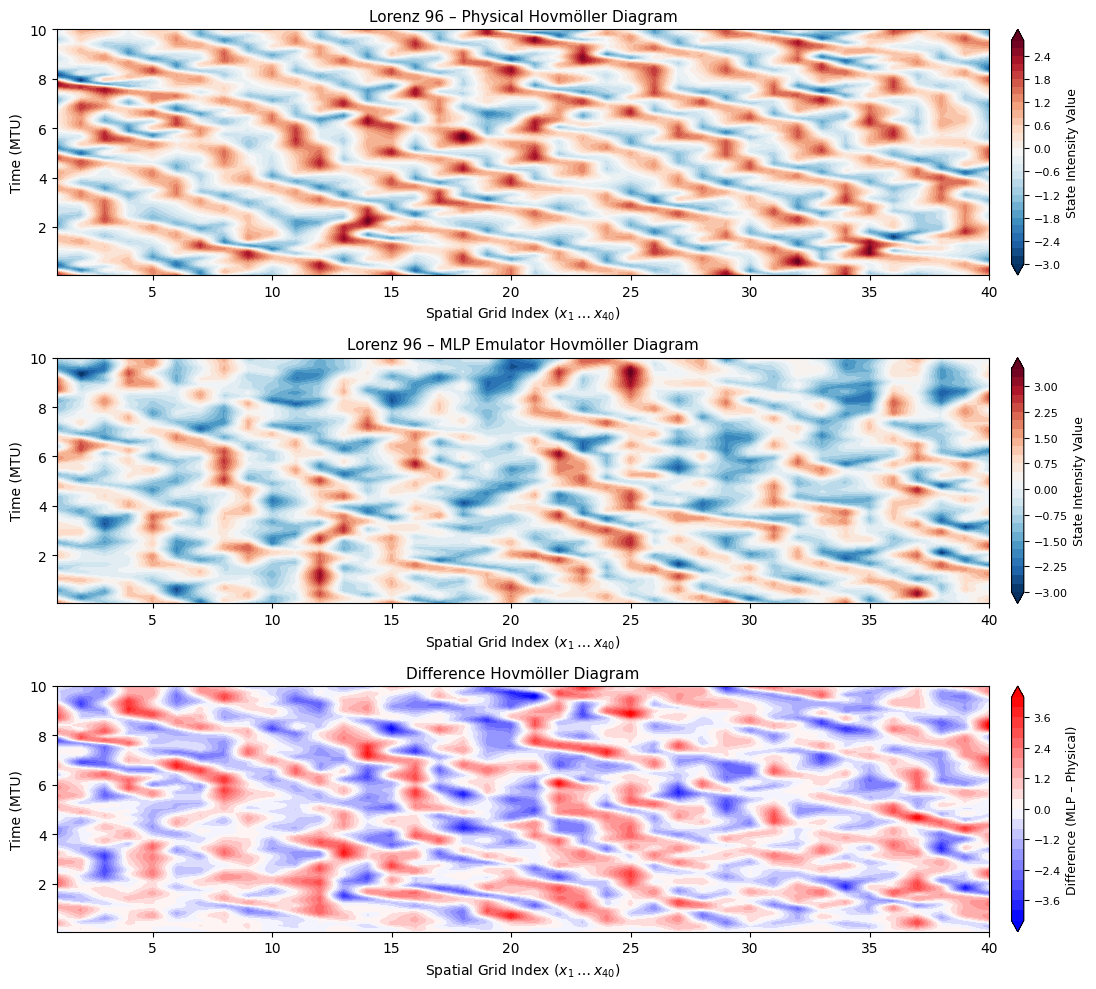

In [15]:
fig = plt.figure(figsize=(12, 10))
# -----------------------------
# 1) Hovmöller fisico
# -----------------------------
ax1 = fig.add_subplot(311)

t_end_hov = 200
hov1 = ax1.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_test_n[WINDOW:t_end_hov+WINDOW, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar1 = plt.colorbar(hov1, ax=ax1, pad=0.02)
cbar1.set_label('State Intensity Value', fontsize=9)
cbar1.ax.tick_params(labelsize=8)

ax1.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax1.set_ylabel('Time (MTU)', fontsize=10)
ax1.set_title('Lorenz 96 – Physical Hovmöller Diagram', fontsize=11)


# -----------------------------
# 2) Hovmöller MLP
# -----------------------------
X96_mlp= autoregressive_forecast(mlp, X96_test_n[0:WINDOW,:], t_end_hov, device="cuda")
ax2 = fig.add_subplot(312)

hov2 = ax2.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_mlp[:t_end_hov, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar2 = plt.colorbar(hov2, ax=ax2, pad=0.02)
cbar2.set_label('State Intensity Value', fontsize=9)
cbar2.ax.tick_params(labelsize=8)

ax2.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax2.set_ylabel('Time (MTU)', fontsize=10)
ax2.set_title('Lorenz 96 – MLP Emulator Hovmöller Diagram', fontsize=11)


# -----------------------------
# 3) Differenza (MLP – Fisico)
# -----------------------------
ax3 = fig.add_subplot(313)

diff = X96_mlp[:t_end_hov, :] - X96_test_n[WINDOW:t_end_hov+WINDOW, :]

hov3 = ax3.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    diff,
    levels=30, cmap='bwr', extend='both'
)

cbar3 = plt.colorbar(hov3, ax=ax3, pad=0.02)
cbar3.set_label('Difference (MLP – Physical)', fontsize=9)
cbar3.ax.tick_params(labelsize=8)

ax3.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax3.set_ylabel('Time (MTU)', fontsize=10)
ax3.set_title('Difference Hovmöller Diagram', fontsize=11)

plt.tight_layout()
plt.savefig("hovmoller_comparison.png", dpi=150)
plt.show()
plt.close()


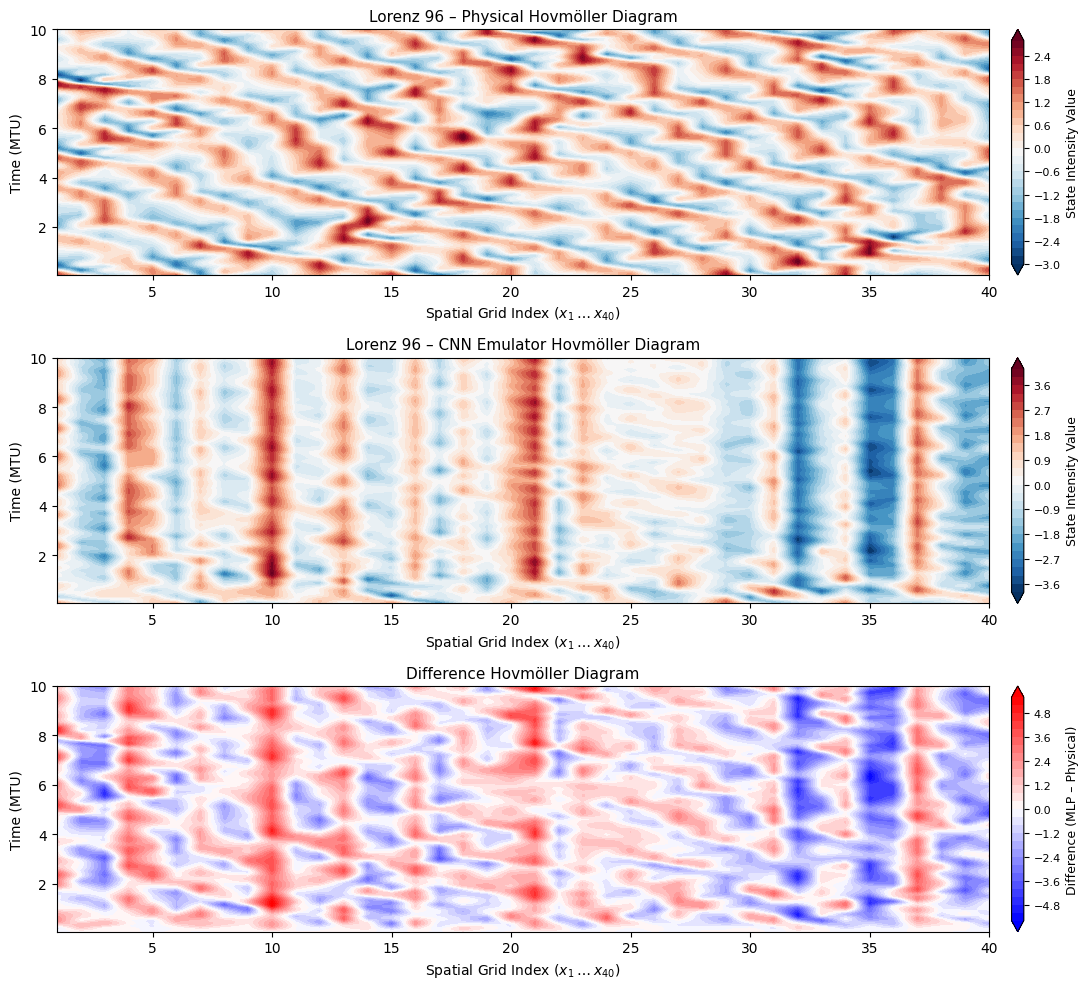

In [16]:
fig = plt.figure(figsize=(12, 10))
# -----------------------------
# 1) Hovmöller fisico
# -----------------------------
ax1 = fig.add_subplot(311)

t_end_hov = 200
hov1 = ax1.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_test_n[WINDOW:t_end_hov+WINDOW, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar1 = plt.colorbar(hov1, ax=ax1, pad=0.02)
cbar1.set_label('State Intensity Value', fontsize=9)
cbar1.ax.tick_params(labelsize=8)

ax1.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax1.set_ylabel('Time (MTU)', fontsize=10)
ax1.set_title('Lorenz 96 – Physical Hovmöller Diagram', fontsize=11)


# -----------------------------
# 2) Hovmöller CNN
# -----------------------------
X96_cnn= autoregressive_forecast(cnn, X96_test_n[0:WINDOW,:], t_end_hov, device="cuda")
ax2 = fig.add_subplot(312)

hov2 = ax2.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_cnn[:t_end_hov, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar2 = plt.colorbar(hov2, ax=ax2, pad=0.02)
cbar2.set_label('State Intensity Value', fontsize=9)
cbar2.ax.tick_params(labelsize=8)

ax2.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax2.set_ylabel('Time (MTU)', fontsize=10)
ax2.set_title('Lorenz 96 – CNN Emulator Hovmöller Diagram', fontsize=11)


# -----------------------------
# 3) Differenza (MLP – Fisico)
# -----------------------------
ax3 = fig.add_subplot(313)

diff = X96_cnn[:t_end_hov, :] - X96_test_n[WINDOW:t_end_hov+WINDOW, :]

hov3 = ax3.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    diff,
    levels=30, cmap='bwr', extend='both'
)

cbar3 = plt.colorbar(hov3, ax=ax3, pad=0.02)
cbar3.set_label('Difference (MLP – Physical)', fontsize=9)
cbar3.ax.tick_params(labelsize=8)

ax3.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax3.set_ylabel('Time (MTU)', fontsize=10)
ax3.set_title('Difference Hovmöller Diagram', fontsize=11)

plt.tight_layout()
plt.savefig("hovmoller_comparison.png", dpi=150)
plt.show()
plt.close()


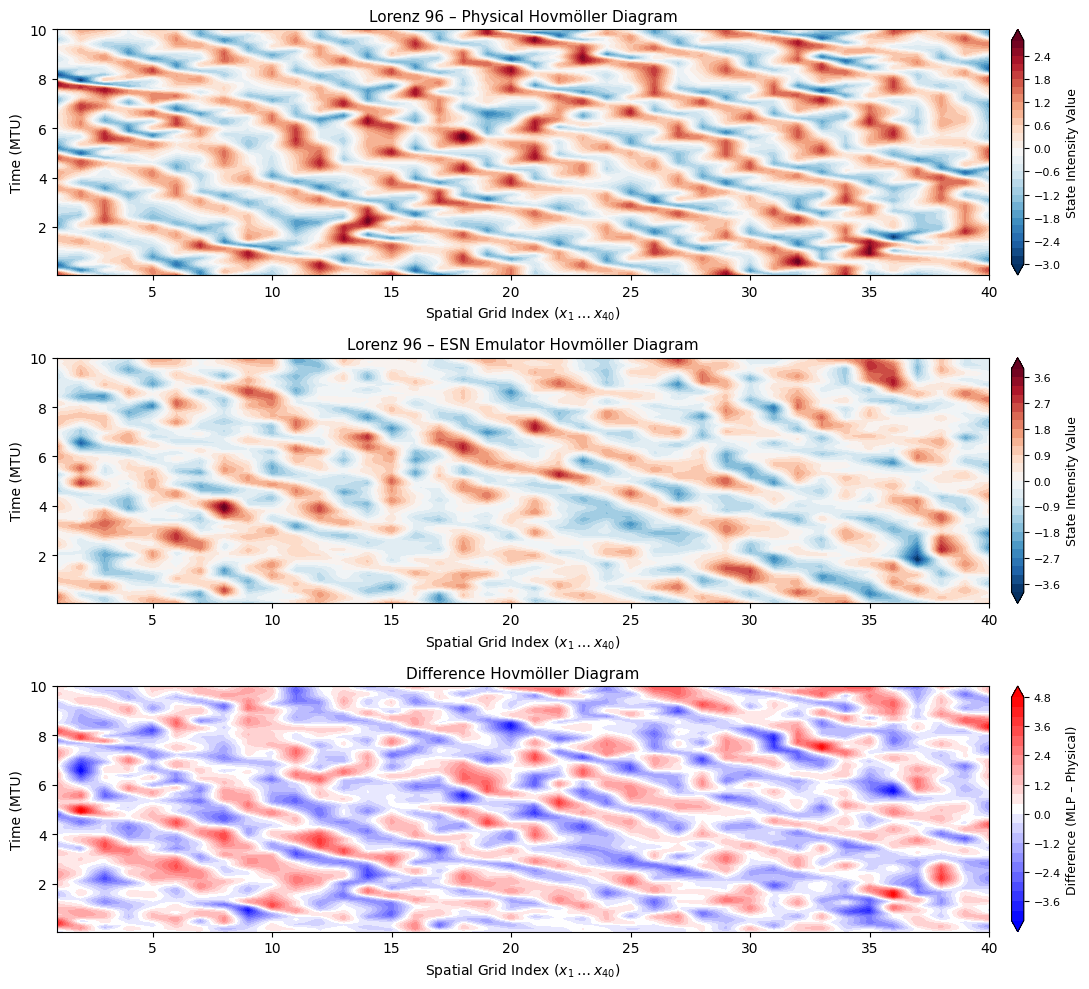

In [17]:
fig = plt.figure(figsize=(12, 10))
# -----------------------------
# 1) Hovmöller fisico
# -----------------------------
ax1 = fig.add_subplot(311)

t_end_hov = 200
hov1 = ax1.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_test_n[WINDOW:t_end_hov+WINDOW, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar1 = plt.colorbar(hov1, ax=ax1, pad=0.02)
cbar1.set_label('State Intensity Value', fontsize=9)
cbar1.ax.tick_params(labelsize=8)

ax1.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax1.set_ylabel('Time (MTU)', fontsize=10)
ax1.set_title('Lorenz 96 – Physical Hovmöller Diagram', fontsize=11)


# -----------------------------
# 2) Hovmöller MLP
# -----------------------------
X96_esn= autoregressive_forecast(esn, X96_test_n[0:WINDOW,:], t_end_hov, device="cuda")
ax2 = fig.add_subplot(312)

hov2 = ax2.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    X96_esn[:t_end_hov, :],
    levels=30, cmap='RdBu_r', extend='both'
)

cbar2 = plt.colorbar(hov2, ax=ax2, pad=0.02)
cbar2.set_label('State Intensity Value', fontsize=9)
cbar2.ax.tick_params(labelsize=8)

ax2.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax2.set_ylabel('Time (MTU)', fontsize=10)
ax2.set_title('Lorenz 96 – ESN Emulator Hovmöller Diagram', fontsize=11)


# -----------------------------
# 3) Differenza (MLP – Fisico)
# -----------------------------
ax3 = fig.add_subplot(313)

diff = X96_esn[:t_end_hov, :] - X96_test_n[WINDOW:t_end_hov+WINDOW, :]

hov3 = ax3.contourf(
    np.arange(1, L96_N + 1),
    t96[:t_end_hov],
    diff,
    levels=30, cmap='bwr', extend='both'
)

cbar3 = plt.colorbar(hov3, ax=ax3, pad=0.02)
cbar3.set_label('Difference (MLP – Physical)', fontsize=9)
cbar3.ax.tick_params(labelsize=8)

ax3.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax3.set_ylabel('Time (MTU)', fontsize=10)
ax3.set_title('Difference Hovmöller Diagram', fontsize=11)

plt.tight_layout()
plt.savefig("hovmoller_comparison.png", dpi=150)
plt.show()
plt.close()


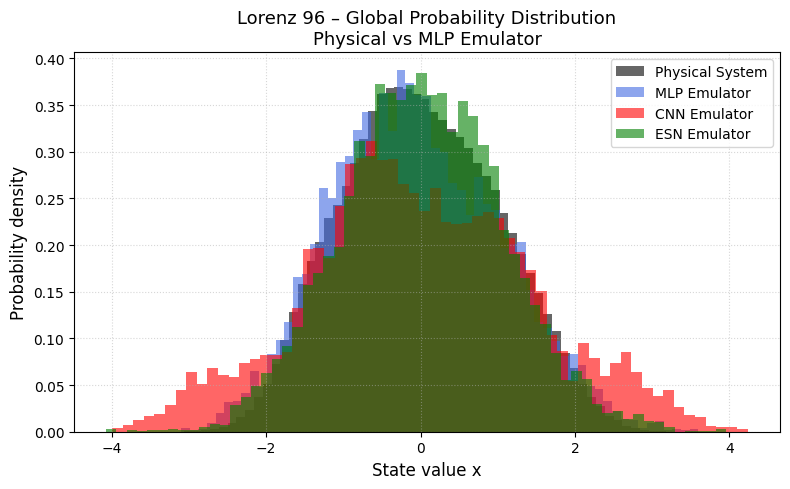

In [19]:
plt.figure(figsize=(8,5))

# Flatten: tutte le variabili, tutti i tempi
phys_data = X96_test_n.reshape(-1)
mlp_data  = X96_mlp.reshape(-1)
cnn_data = X96_cnn.reshape(-1)
esn_data = X96_esn.reshape(-1)

plt.hist(phys_data, bins=60, density=True, alpha=0.6,
         color='black', label='Physical System')

plt.hist(mlp_data, bins=60, density=True, alpha=0.6,
         color='royalblue', label='MLP Emulator')

plt.hist(cnn_data, bins=60, density=True, alpha=0.6,
         color='red', label='CNN Emulator')

plt.hist(esn_data, bins=60, density=True, alpha=0.6,
         color='green', label='ESN Emulator')

plt.xlabel("State value x", fontsize=12)
plt.ylabel("Probability density", fontsize=12)
plt.title("Lorenz 96 – Global Probability Distribution\nPhysical vs MLP Emulator", fontsize=13)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


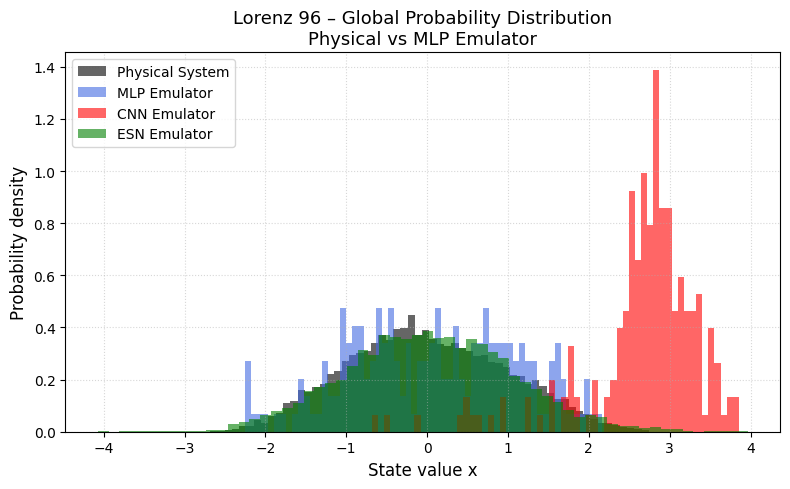

In [20]:
plt.figure(figsize=(8,5))

# Flatten: tutte le variabili, tutti i tempi
phys_data = X96_test_n[:,20].reshape(-1)
mlp_data  = X96_mlp[:,20].reshape(-1)
cnn_data = X96_cnn[:,20].reshape(-1)
esn_data = X96_esn.reshape(-1)

plt.hist(phys_data, bins=60, density=True, alpha=0.6,
         color='black', label='Physical System')

plt.hist(mlp_data, bins=60, density=True, alpha=0.6,
         color='royalblue', label='MLP Emulator')

plt.hist(cnn_data, bins=60, density=True, alpha=0.6,
         color='red', label='CNN Emulator')

plt.hist(esn_data, bins=60, density=True, alpha=0.6,
         color='green', label='ESN Emulator')

plt.xlabel("State value x", fontsize=12)
plt.ylabel("Probability density", fontsize=12)
plt.title("Lorenz 96 – Global Probability Distribution\nPhysical vs MLP Emulator", fontsize=13)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
